# About the Data
This dataset contains outputs from a computer-based analysis of hurricane impacts across the Yucatán Peninsula from 1851 to 2000. Using the HURRECON meteorological model in combination with historical hurricane records from the U.S. National Hurricane Center’s HURDAT database, the study reconstructed all storms with sustained winds of at least 33 m/s occurring within 300 km of the region (n = 105). For each hurricane, the model estimated spatial patterns of wind damage using the Fujita scale. These individual storm reconstructions were then compiled to assess cumulative disturbance intensity, spatial gradients of hurricane impacts, and long-term temporal trends in hurricane activity.

Accessed 11/16/2025

[Ecological Impacts of Hurricanes Across the Yucatan Peninsula 1851-2000](https://doi.org/10.6073/pasta/f219113373913f2daf421732e28d3c38)

In [1]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load Data
df = pd.read_csv('data/hf071-01-hurricanes.csv')

In [3]:
df.shape

(105, 8)

In [4]:
df.head(10)

,code,start.date,end.date,number,name,ss,track,rf.max
0,Y1852,1852-10-07,1852-10-08,5,NaN,2,O,F1
1,Y1857,1857-09-28,1857-09-28,4,NaN,2,N,F1
2,Y1861,1861-08-17,1861-08-17,2,NaN,1,O,Nd
3,Y1864,1864-08-31,1864-08-31,3,NaN,1,S,F1
4,Y1865,1865-09-11,1865-09-11,4,NaN,2,O,F1
5,Y1866,1866-08-16,1866-08-16,2,NaN,1,N,F1
6,Y1868,1868-10-07,1868-10-07,3,NaN,2,O,F1
7,Y1870,1870-10-31,1870-11-02,11,NaN,1,N,F1
8,Y1873,1873-10-04,1873-10-05,5,NaN,2,O,F2
9,Y1877,1877-09-28,1877-09-29,4,NaN,1,O,F1


In [5]:
df.dtypes

code          object
start.date    object
end.date      object
number         int64
name          object
ss             int64
track         object
rf.max        object
dtype: object

#### Question: How many hurricanes with Saffir-Simpson category 5 have been registered and what was their duration?

#### Brainstorm:
- Identify column with Saffir-Simpson category info --> 'ss' col
- Transform date columns to date objects? 
- Subset to category 5 only
- Hardest part will be calculating duration

In [6]:
# Subset to category 5
cat_5 = df[df['ss'] == 5].copy()

In [7]:
# Change 'ss' column to data type datetime in subset df

cat_5['start.date'] = pd.to_datetime(cat_5['start.date'])
cat_5['end.date'] = pd.to_datetime(cat_5['end.date'])

cat_5.dtypes

# Change 'ss' column to data type datetime for entire df
df['start.date'] = pd.to_datetime(df['start.date'])
df['end.date'] = pd.to_datetime(df['end.date'])

print(min(df['start.date']))
print(max(df['start.date']))

1852-10-07 00:00:00
2000-10-01 00:00:00


In [8]:
# Find event durations and turn to hours 

cat_5['duration'] = (cat_5['end.date'] - cat_5['start.date']).dt.total_seconds()/3600

cat_5.head(4)

,code,start.date,end.date,number,name,ss,track,rf.max,duration
76,Y1955b,1955-09-28,1955-09-28,10,Janet,5,N,F3,0.0
96,Y1980a,1980-08-07,1980-08-08,1,Allen,5,O,F3,24.0
98,Y1988,1988-09-14,1988-09-15,8,Gilbert,5,N,F3,24.0
103,Y1998,1998-10-27,1998-10-28,13,Mitch,5,S,F1,24.0


Create a scatter plot of the start date of the hurricanes against the Saffir-Simpson scale. Customize your graph, including updating the tick labels to be only 1, 2, 3, 4, and 5 since the Saffir-Simpsn scale does not take decimal values.

Text(0.5, 0, 'Date')

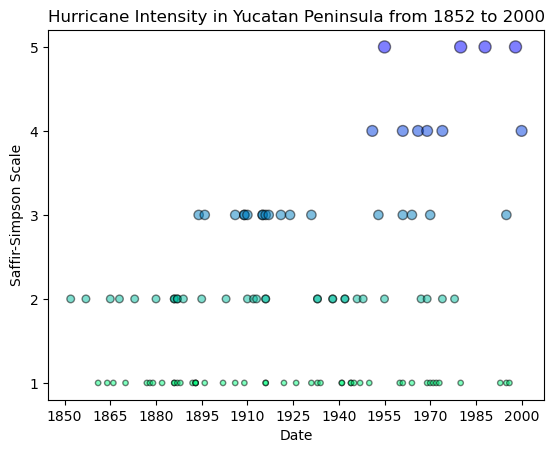

In [9]:
# Plot hurricanes against the Saffir-Simpson scale 

plt.scatter(y = df['ss'],
            x = df['start.date'].dt.year, # Convert date to an integer year 
            s = df['ss']*15,
            c = df['ss'],
           cmap = 'winter_r',
           alpha = 0.5,
           edgecolor = 'black') # Points grow with 'ss', multiply by 15 to make size difference more noticeable

ax = plt.gca() # Find axis where scatter is plot

ax.set_title('Hurricane Intensity in Yucatan Peninsula from 1852 to 2000')
ax.set_yticks([1, 2, 3, 4, 5]) # Set y axis tick marks to the ratings in the Saffir-Simpson scale
ax.set_xticks(range(1850, 2001, 15)) # Show time range in x axis in 15 year increments
ax.set_ylabel('Saffir-Simpson Scale')
ax.set_xlabel('Date')

The scatter plot of hurricanes in the Yucatan peninsula from 1852 to 2000 shows a trend: Overtime, the number of hurricanes have decreased but their intensity has increased in the Saffir-Simpson scale. Alternatively, it's possible that the Saffir-Simpson scale was created recently and that is why we only see category 4 and 5 hurricanes in recent years OR that the scale recently started to categorize hurricanes differently.

Text(0, 0.5, 'Saffir-Simpson Scale')

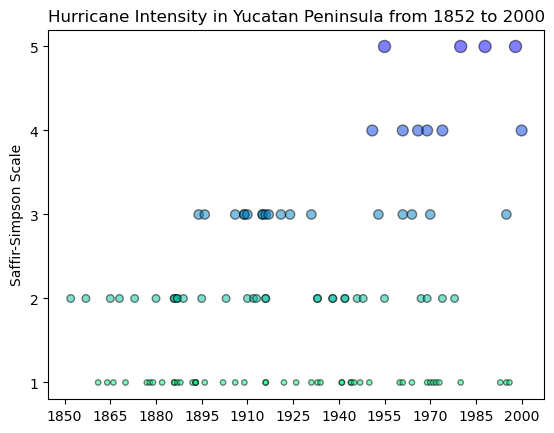

In [11]:
# COMPLETE WORKFLOW

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Data
df = pd.read_csv('data/hf071-01-hurricanes.csv')

# Subset to category 5 hurricanes
cat_5 = df[df['ss'] == 5].copy()

# Change 'ss' column to data type datetime in subset df
cat_5['start.date'] = pd.to_datetime(cat_5['start.date'])
cat_5['end.date'] = pd.to_datetime(cat_5['end.date'])

# Change 'ss' column to data type datetime for entire df
df['start.date'] = pd.to_datetime(df['start.date'])
df['end.date'] = pd.to_datetime(df['end.date'])

# Plot hurricanes against the Saffir-Simpson scale 
plt.scatter(y = df['ss'],
            x = df['start.date'].dt.year, # Convert date to an integer year 
            s = df['ss']*15,
            c = df['ss'],
           cmap = 'winter_r',
           alpha = 0.5,
           edgecolor = 'black') # Points grow with 'ss', multiply by 15 to make size difference more noticeable

ax = plt.gca() # Find axis where scatter is plot

ax.set_title('Hurricane Intensity in Yucatan Peninsula from 1852 to 2000')
ax.set_yticks([1, 2, 3, 4, 5]) # Set y axis tick marks to the ratings in the Saffir-Simpson scale
ax.set_xticks(range(1850, 2001, 15)) # Show time range in x axis in 15 year increments
ax.set_ylabel('Saffir-Simpson Scale')